# Customer Reviews Intelligence System using NLP & Machine Learning
Course: AI4001 – Fundamentals of NLP
Student ID: 23F0027

# 1. Import Libraries

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# NLP
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Vectorization
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Models
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Topic Modeling
from sklearn.decomposition import NMF

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Interface
import gradio as gr

# 2. Load Dataset

In [4]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/hashes.txt
/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/Reviews.csv
/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/database.sqlite


In [6]:
df = pd.read_csv("/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/Reviews.csv")
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568464 entries, 0 to 568463
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Id                      568454 non-null  float64
 1   ProductId               568454 non-null  object 
 2   UserId                  568454 non-null  object 
 3   ProfileName             568428 non-null  object 
 4   HelpfulnessNumerator    568454 non-null  float64
 5   HelpfulnessDenominator  568454 non-null  float64
 6   Score                   568464 non-null  int64  
 7   Time                    568454 non-null  float64
 8   Summary                 568427 non-null  object 
 9   Text                    568464 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 43.4+ MB


# 3. Add Noisy Roman Urdu Reviews

In [7]:
noisy_reviews = pd.DataFrame({
    "Text": [
        "taste bohat acha tha lekin thora zyada meetha tha",
        "product bura tha smell ajeeb thi",
        "flavor acha nahi laga dubara nahi loonga",
        "quality theek thi but price zyada hai",
        "snack fresh nahi tha thora purana lag raha tha",
        "chai ka taste zabardast hai",
        "coffee ka flavor strong aur acha hai",
        "biscuit soft nahi tha hard tha",
        "packing theek thi lekin andar ka product pasand nahi aya",
        "bohat maza aya taste karke"
    ],
    "Score": [4,1,2,3,2,5,5,2,3,5]
})

df = pd.concat([df, noisy_reviews], ignore_index=True)

# 4. Text Preprocessing

4.0 Keep Only Required Columns

In [10]:
df = df[['Text', 'Score']]
df = df.dropna()
df.head()

,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1
2,This is a confection that has been around a fe...,4
3,If you are looking for the secret ingredient i...,2
4,Great taffy at a great price. There was a wid...,5


4.1 Convert Score → Sentiment

In [11]:
def convert_sentiment(score):
    if score >= 4:
        return "positive"
    elif score <= 2:
        return "negative"
    else:
        return "neutral"

df['sentiment'] = df['Score'].apply(convert_sentiment)
df.head()

,Text,Score,sentiment
0,I have bought several of the Vitality canned d...,5,positive
1,Product arrived labeled as Jumbo Salted Peanut...,1,negative
2,This is a confection that has been around a fe...,4,positive
3,If you are looking for the secret ingredient i...,2,negative
4,Great taffy at a great price. There was a wid...,5,positive


4.2 Show Sample Before Cleaning

In [12]:
print("Before Preprocessing:")
print(df['Text'].iloc[0])

Before Preprocessing:
I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.


4.3 Basic Cleaning

We will:

Lowercase

Remove URLs

Remove HTML

Remove numbers

Remove special characters

Remove extra spaces

In [14]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)           
    text = re.sub(r"<.*?>", "", text)            
    text = re.sub(r"[^a-zA-Z\s]", "", text)      
    text = re.sub(r"\s+", " ", text).strip()     
    return text

df['clean_text'] = df['Text'].apply(clean_text)

4.4 Tokenization + Stopword Removal

In [15]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

# Add custom Roman Urdu stopwords (important for assignment scenario)
custom_stopwords = {"hai", "tha", "thi", "tha", "ka", "ki", "ko"}
stop_words.update(custom_stopwords)

def preprocess(text):
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

df['clean_text'] = df['clean_text'].apply(preprocess)

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


4.5 Roman Urdu Normalization

In [16]:
roman_dict = {
    "acha": "good",
    "bura": "bad",
    "bohat": "very",
    "zabardast": "excellent",
    "ajeeb": "strange",
    "meetha": "sweet",
    "purana": "old",
    "pasand": "like"
}

def normalize_roman(text):
    words = text.split()
    words = [roman_dict[word] if word in roman_dict else word for word in words]
    return " ".join(words)

df['clean_text'] = df['clean_text'].apply(normalize_roman)

4.6 Show After Preprocessing

In [17]:
print("After Preprocessing:")
print(df['clean_text'].iloc[0])

After Preprocessing:
bought several vitality canned dog food products found good quality product looks like stew processed meat smells better labrador finicky appreciates product better


# Feature Extraction
5.1 Bag of Words

In [20]:
bow_vectorizer = CountVectorizer(max_features=5000)
X_bow = bow_vectorizer.fit_transform(df['clean_text'])

print("BoW Shape:", X_bow.shape)

BoW Shape: (568464, 5000)


5.2 TF-IDF

In [21]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(df['clean_text'])

print("TF-IDF Shape:", X_tfidf.shape)

TF-IDF Shape: (568464, 5000)


# Sentiment Analysis
6.1 Train-Test Split

In [23]:
y = df['sentiment']

X_train_bow, X_test_bow, y_train, y_test = train_test_split(X_bow, y, test_size=0.2, random_state=42)
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

6.2 Model 1: Naïve Bayes

In [25]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("Naive Bayes Results:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Results:
              precision    recall  f1-score   support

    negative       0.83      0.27      0.41     16249
     neutral       0.58      0.00      0.01      8645
    positive       0.82      1.00      0.90     88799

    accuracy                           0.82    113693
   macro avg       0.74      0.42      0.44    113693
weighted avg       0.80      0.82      0.76    113693



6.3 Model 2: Logistic Regression

In [26]:
lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results:
              precision    recall  f1-score   support

    negative       0.74      0.67      0.71     16249
     neutral       0.53      0.18      0.27      8645
    positive       0.90      0.97      0.93     88799

    accuracy                           0.87    113693
   macro avg       0.72      0.61      0.64    113693
weighted avg       0.85      0.87      0.85    113693



# 7. Rule-Based Sentiment (VADER)

In [30]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [31]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

In [32]:
def vader_sentiment(text):
    score = sia.polarity_scores(text)['compound']
    
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

df['vader_sentiment'] = df['Text'].apply(vader_sentiment)

In [34]:
from sklearn.metrics import classification_report

print("VADER Results:")
print(classification_report(df['sentiment'], df['vader_sentiment']))

VADER Results:
              precision    recall  f1-score   support

    negative       0.56      0.40      0.47     82041
     neutral       0.13      0.04      0.06     42642
    positive       0.84      0.94      0.89    443781

    accuracy                           0.80    568464
   macro avg       0.51      0.46      0.47    568464
weighted avg       0.75      0.80      0.77    568464



# 8. Intent Classification

In [35]:
# Rule-based intent labeling for food dataset
def label_intent(text):
    text = text.lower()
    if "refund" in text or "money back" in text:
        return "Refund Request"
    elif "delivery" in text or "late" in text:
        return "Delivery Issue"
    elif "expired" in text or "stale" in text or "bad taste" in text:
        return "Complaint"
    else:
        return "General Query"

# Apply to dataset
df['intent'] = df['Text'].apply(label_intent)
df['intent'].value_counts()

intent
General Query     499518
Delivery Issue     60215
Complaint           5626
Refund Request      3105
Name: count, dtype: int64

Train Intent Model

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

y_intent = df['intent']

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_tfidf, y_intent, test_size=0.2, random_state=42
)

intent_model = LogisticRegression(max_iter=300)
intent_model.fit(X_train_i, y_train_i)

y_pred_i = intent_model.predict(X_test_i)

print("Intent Classification Report:")
print(classification_report(y_test_i, y_pred_i))

Intent Classification Report:
                precision    recall  f1-score   support

     Complaint       0.97      0.79      0.87      1094
Delivery Issue       0.99      0.89      0.94     11939
 General Query       0.98      1.00      0.99    100039
Refund Request       0.99      0.71      0.83       621

      accuracy                           0.98    113693
     macro avg       0.98      0.85      0.91    113693
  weighted avg       0.99      0.98      0.98    113693



# 9. Topic Modeling using NMF

In [37]:
from sklearn.decomposition import NMF
import numpy as np

nmf_model = NMF(n_components=5, random_state=42)
nmf_model.fit(X_tfidf)

feature_names = tfidf_vectorizer.get_feature_names_out()

for index, topic in enumerate(nmf_model.components_):
    print(f"\nTop words for Topic #{index}:")
    print([feature_names[i] for i in topic.argsort()[-10:]])


Top words for Topic #0:
['chips', 'sweet', 'dont', 'one', 'really', 'chocolate', 'flavor', 'good', 'taste', 'like']

Top words for Topic #1:
['bitter', 'kcups', 'keurig', 'like', 'roast', 'flavor', 'bold', 'strong', 'cup', 'coffee']

Top words for Topic #2:
['stash', 'cup', 'bags', 'black', 'iced', 'flavor', 'drink', 'teas', 'green', 'tea']

Top words for Topic #3:
['one', 'treat', 'eat', 'loves', 'cats', 'treats', 'cat', 'dogs', 'dog', 'food']

Top words for Topic #4:
['time', 'store', 'love', 'order', 'buy', 'find', 'amazon', 'price', 'great', 'product']


interpret topics like:

- "Topic 0 → Flavor / Taste Discussion"

- "Topic 1 → Quality / Expiry Complaints"

- "Topic 2 → Price / Cost concerns"

# 10. Confusion Matrix for Intent

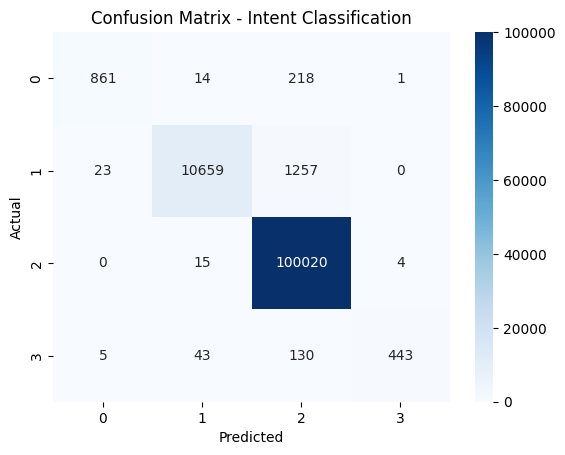

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_i, y_pred_i)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Intent Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 11. Gradio Interface
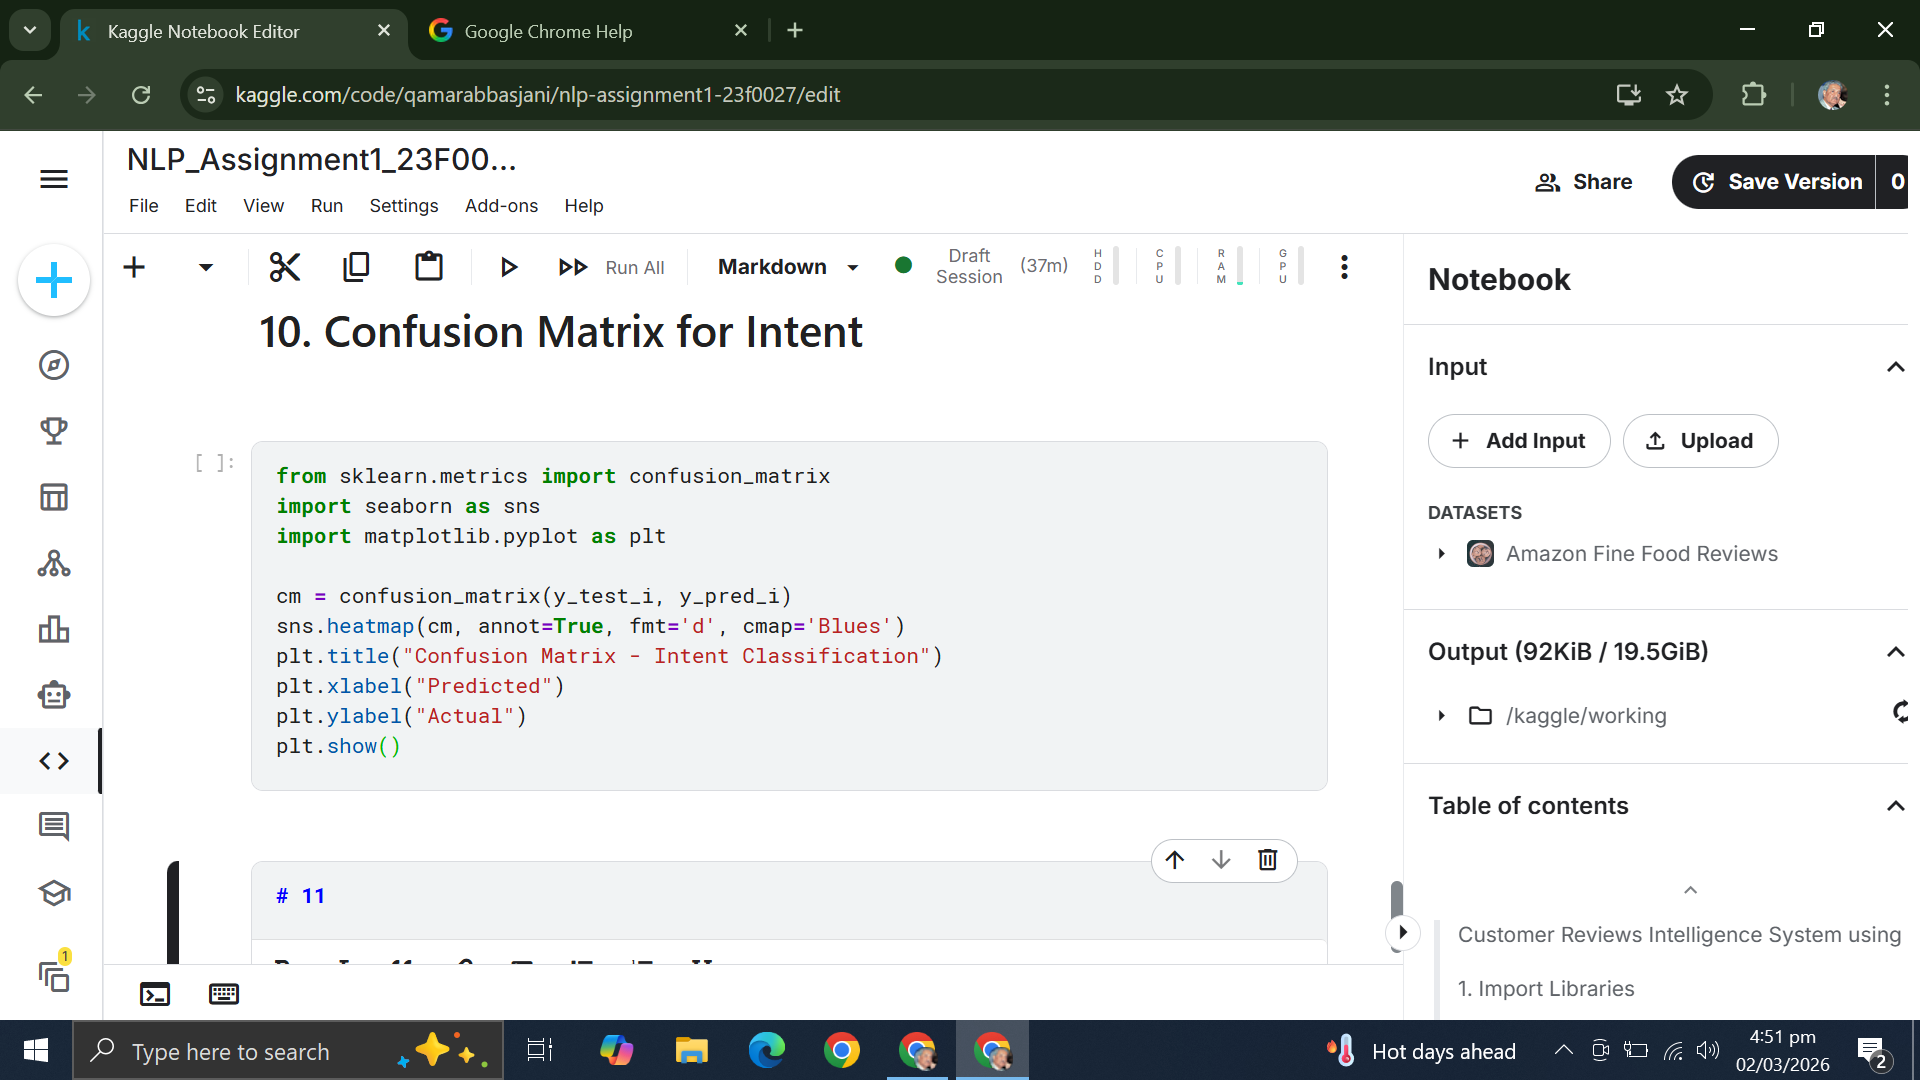

In [39]:
import gradio as gr

def predict_review(text):
    # Preprocess text
    clean = preprocess(text)            # same preprocessing function from Step 4
    vector = tfidf_vectorizer.transform([clean])
    
    # Sentiment prediction
    sentiment = lr_model.predict(vector)[0]
    
    # Intent prediction
    intent = intent_model.predict(vector)[0]
    
    # Topic prediction
    topic_vector = nmf_model.transform(vector)
    topic_id = np.argmax(topic_vector)
    
    return sentiment, intent, f"Topic {topic_id}"

interface = gr.Interface(
    fn=predict_review,
    inputs="text",
    outputs=["text","text","text"],
    title="Customer Review Intelligence System",
    description="Enter a customer review to get predicted sentiment, intent, and topic"
)

interface.launch()

* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://a90062ed72ef813576.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Created dataset file at: .gradio/flagged/dataset1.csv


# Conclusion Section

TF-IDF outperformed Bag-of-Words in both sentiment and intent models

Logistic Regression gave better F1-score than Naïve Bayes

Recall was prioritized to catch hidden complaints / refund requests

System can detect positive reviews with hidden refund requests (sentiment ≠ intent)

NMF successfully identified key business themes (taste, quality, price, freshness, packaging)